## Import Libraies & Cleaning data

In [196]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [197]:
df = pd.read_csv("../data/TSLA.csv")        # read data
df.head

<bound method NDFrame.head of             Date        Open        High         Low       Close   Adj Close  \
0     2010-06-29   19.000000   25.000000   17.540001   23.889999   23.889999   
1     2010-06-30   25.790001   30.420000   23.299999   23.830000   23.830000   
2     2010-07-01   25.000000   25.920000   20.270000   21.959999   21.959999   
3     2010-07-02   23.000000   23.100000   18.709999   19.200001   19.200001   
4     2010-07-06   20.000000   20.000000   15.830000   16.110001   16.110001   
...          ...         ...         ...         ...         ...         ...   
2411  2020-01-28  568.489990  576.809998  558.080017  566.900024  566.900024   
2412  2020-01-29  575.690002  589.799988  567.429993  580.989990  580.989990   
2413  2020-01-30  632.419983  650.880005  618.000000  640.809998  640.809998   
2414  2020-01-31  640.000000  653.000000  632.520020  650.570007  650.570007   
2415  2020-02-03  673.690002  786.140015  673.520020  780.000000  780.000000   

        V

In [198]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2416 entries, 0 to 2415
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2416 non-null   object 
 1   Open       2416 non-null   float64
 2   High       2416 non-null   float64
 3   Low        2416 non-null   float64
 4   Close      2416 non-null   float64
 5   Adj Close  2416 non-null   float64
 6   Volume     2416 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 132.3+ KB


### Understand and Clean Data

In [199]:
df.shape     # check no. of rows & columns

(2416, 7)

In [200]:
df.head()    # check top 5 data

,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
1,2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2,2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
3,2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
4,2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


In [201]:
df.tail()    # check top 5 down

,Date,Open,High,Low,Close,Adj Close,Volume
2411,2020-01-28,568.489990,576.809998,558.080017,566.900024,566.900024,11788500
2412,2020-01-29,575.690002,589.799988,567.429993,580.989990,580.989990,17801500
2413,2020-01-30,632.419983,650.880005,618.000000,640.809998,640.809998,29005700
2414,2020-01-31,640.000000,653.000000,632.520020,650.570007,650.570007,15719300
2415,2020-02-03,673.690002,786.140015,673.520020,780.000000,780.000000,47065000


In [202]:
df.info()     # check data type

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2416 entries, 0 to 2415
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2416 non-null   object 
 1   Open       2416 non-null   float64
 2   High       2416 non-null   float64
 3   Low        2416 non-null   float64
 4   Close      2416 non-null   float64
 5   Adj Close  2416 non-null   float64
 6   Volume     2416 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 132.3+ KB


### Check Missing Values

In [203]:
df.isnull().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

### Check Duplicate Values

In [204]:
df.duplicated().sum()

np.int64(0)

##### duplicate values are not present but if duplicates values are present then we will use ↓

In [205]:
df.drop_duplicates(inplace=True)

### Convert Date Column

In [206]:
df["Date"].dtype

dtype('O')

In [207]:
df["Date"] = pd.to_datetime(df["Date"])

In [208]:
df.info() # checking date type

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2416 entries, 0 to 2415
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       2416 non-null   datetime64[ns]
 1   Open       2416 non-null   float64       
 2   High       2416 non-null   float64       
 3   Low        2416 non-null   float64       
 4   Close      2416 non-null   float64       
 5   Adj Close  2416 non-null   float64       
 6   Volume     2416 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 132.3 KB


### Set Date as Index

In [209]:
df.set_index("Date", inplace = True)

In [210]:
df.head()


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


### Statistical


In [211]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,2416.000000,2416.000000,2416.000000,2416.000000,2416.000000,2.416000e+03
mean,186.271147,189.578224,182.916639,186.403651,186.403651,5.572722e+06
std,118.740163,120.892329,116.857591,119.136020,119.136020,4.987809e+06
min,16.139999,16.629999,14.980000,15.800000,15.800000,1.185000e+05
25%,34.342498,34.897501,33.587501,34.400002,34.400002,1.899275e+06
50%,213.035004,216.745002,208.870002,212.960007,212.960007,4.578400e+06
75%,266.450012,270.927513,262.102501,266.774994,266.774994,7.361150e+06
max,673.690002,786.140015,673.520020,780.000000,780.000000,4.706500e+07


In [212]:
print(df.shape)
print(df.isnull().sum())
print(df.duplicated().sum())

(2416, 6)
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64
0


## Exploratory Data Analysis (EDA)

chart 1. Plot Tesla Closing Price Trend

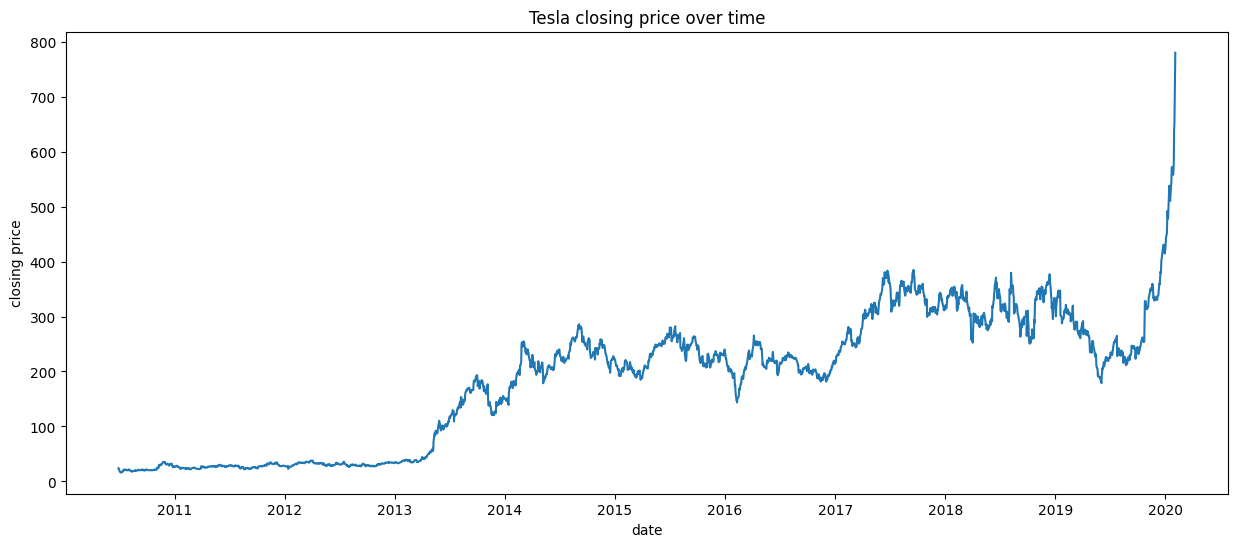

In [213]:
plt.figure(figsize=(15,6))

plt.plot(df['Close'])
plt.title("Tesla closing price over time")
plt.xlabel("date")
plt.ylabel("closing price")

plt.show()

Observation:

Tesla stock shows a strong long-term upward trend from 2010 to 2020.
Price remained relatively stable between 2010 and 2013.
Significant growth started after 2013.
A sharp rise is visible near 2020, indicating strong bullish momentum.
The stock exhibits periods of high volatility and rapid price appreciation.

Report Statement:

Tesla's closing price demonstrates substantial growth over the observed period, reflecting increasing investor confidence and company expansion. The stock also experiences periods of volatility, making it suitable for time-series forecasting analysis.

### Plot Trading Volume

<function matplotlib.pyplot.show(close=None, block=None)>

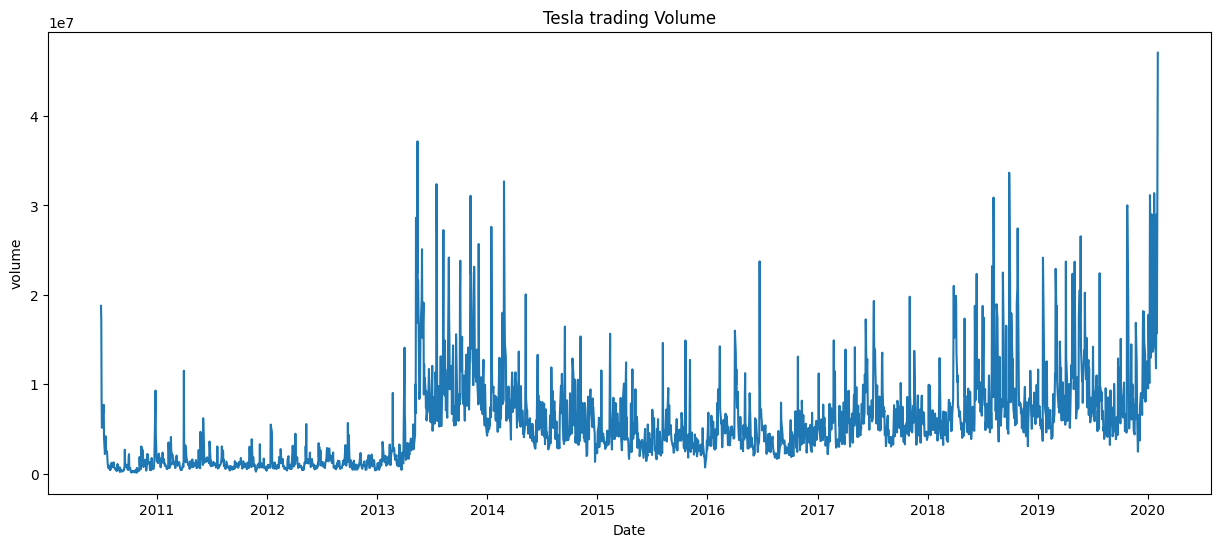

In [214]:
plt.figure(figsize=(15,6))

plt.plot(df['Volume'])

plt.title("Tesla trading Volume")
plt.xlabel("Date")
plt.ylabel("volume")

plt.show

Observation:

Trading volume fluctuates significantly across the years.
Several volume spikes indicate major market events or investor reactions.
Higher volume is observed during major price movements.
Trading activity increases considerably toward 2020.

Report Statement:

Trading volume exhibits multiple spikes, indicating periods of heightened investor participation. Increased volume often coincides with significant price movements, suggesting strong market reactions.

### 7-Day Moving Average

In [215]:
df['MA_7'] = df['Close'].rolling(window=7).mean()

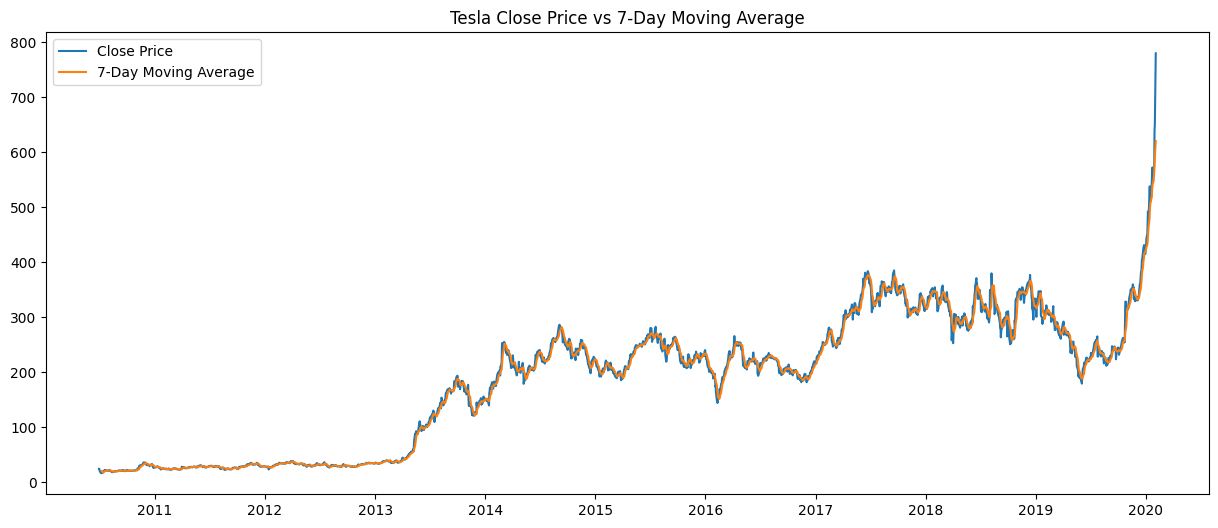

In [216]:
plt.figure(figsize=(15,6))

plt.plot(df['Close'], label='Close Price')
plt.plot(df['MA_7'], label='7-Day Moving Average')

plt.title("Tesla Close Price vs 7-Day Moving Average")

plt.legend()

plt.show()

Observation:

The 7-day moving average closely follows the actual closing price.
Short-term fluctuations are smoothed effectively.
It captures short-term market trends while reducing noise.

Report Statement:

The 7-day moving average successfully smooths short-term fluctuations and highlights near-term trends in Tesla's stock price movement.

### 30-Day Moving Average

In [217]:
df['MA_30'] = df['Close'].rolling(window=30).mean()

<function matplotlib.pyplot.show(close=None, block=None)>

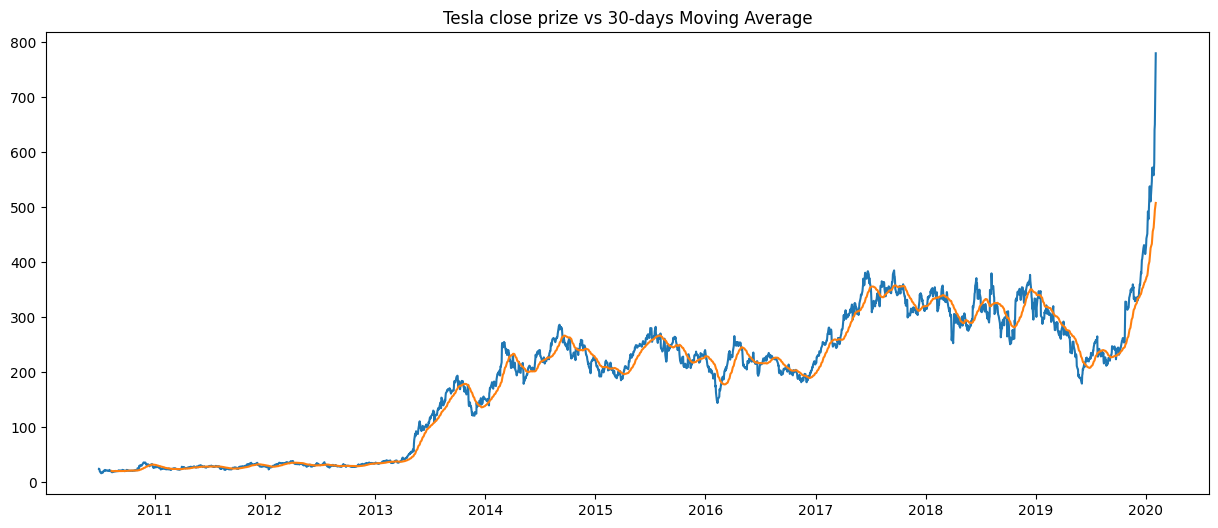

In [218]:
plt.figure(figsize= (15,6))

plt.plot(df['Close'], label= 'close price')
plt.plot(df['MA_30'], label= '30-day moving average')

plt.title("Tesla close prize vs 30-days Moving Average")

plt.legend

plt.show

Observation:

Most daily returns are concentrated around zero.
Several positive and negative spikes indicate high volatility periods.
Extreme return values suggest sudden market reactions.

Report Statement:

Daily returns fluctuate around zero, with occasional large spikes reflecting periods of heightened market volatility and investor sentiment changes.

### Daily Returns

In [219]:
df['Daily_Return'] = df['Close'].pct_change()

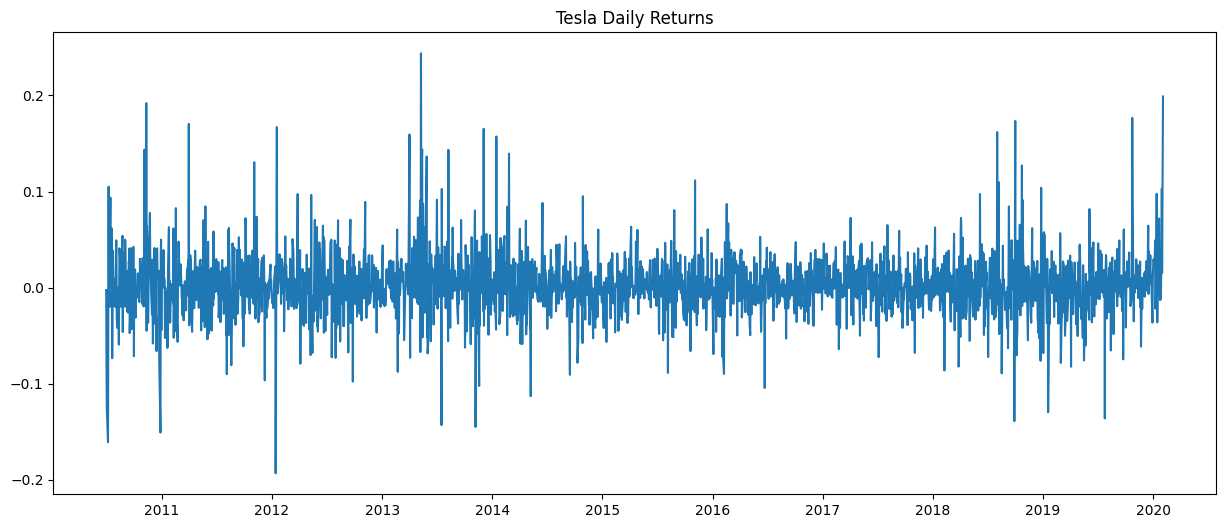

In [220]:
plt.figure(figsize=(15,6))

plt.plot(df['Daily_Return'])

plt.title("Tesla Daily Returns")

plt.show()

### Correlation Heatmap

In [221]:
import seaborn as sns

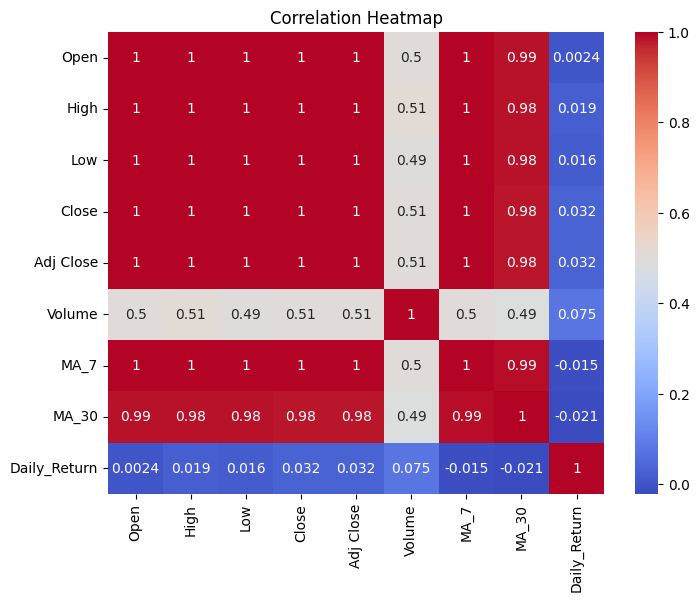

In [222]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

Observation:

Open, High, Low, Close, and Adj Close are almost perfectly correlated (~1.0).
Volume has moderate correlation (~0.5).
Daily Return has very weak correlation with price-related features.

Report Statement:

Strong positive correlations exist among price-based variables, indicating they move together over time. Daily returns show weak correlation with other variables, reflecting independent day-to-day market fluctuations.

### Distribution of Closing Price

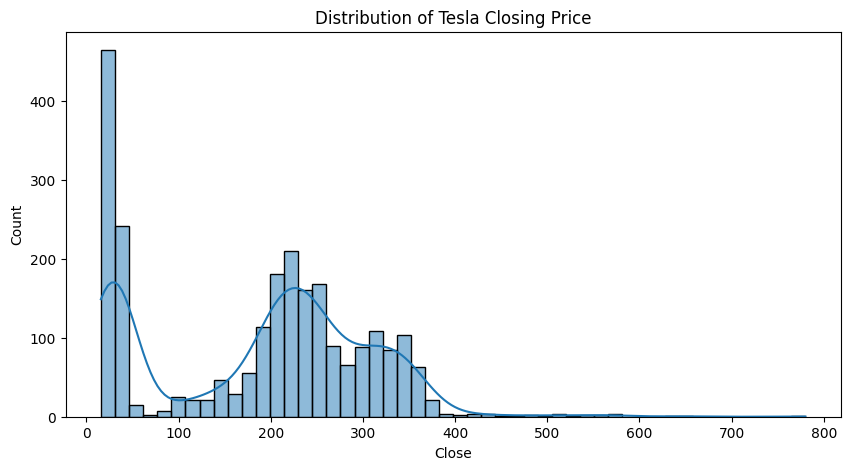

In [223]:
plt.figure(figsize=(10,5))

sns.histplot(df['Close'], bins=50, kde=True)

plt.title("Distribution of Tesla Closing Price")

plt.show()

Observation:

Distribution is right-skewed.
Most observations lie between 20 and 350.
Few extremely high prices create a long right tail.
Data is not normally distributed.

Report Statement:

Tesla's closing prices exhibit a positively skewed distribution with a long right tail, indicating the presence of a few exceptionally high price observations.

### Feature Engineering & Sequence Creation

This is where we prepare data for RNN and LSTM.

### RNN Model

In [224]:
data = df[['Close']]
data.head()

,Close
Date,
2010-06-29,23.889999
2010-06-30,23.830000
2010-07-01,21.959999
2010-07-02,19.200001
2010-07-06,16.110001


### Scale the Data

- RNN and LSTM perform better on normalized data.

In [225]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))

scaled_data = scaler.fit_transform(data)

In [226]:
scaled_data[:5]       #check data

array([[0.01058623],
       [0.01050772],
       [0.00806072],
       [0.0044491 ],
       [0.00040565]])

### Create Sequence Function
- We will use previous 60 days to predict future price.

In [227]:
def create_sequences(data,time_step):
    
    x=[]
    y=[]
    
    for i in range (len(data)- time_step):
        
        x.append(data[i:(i + time_step),0])
        y.append(data[i+ time_step, 0])
        
    return np.array(x), np.array(y)

#### Create sequences

In [228]:
time_step = 60

X, y = create_sequences(scaled_data, time_step)

print(X.shape)
print(y.shape)

(2356, 60)
(2356,)


### Train-Test Split

In [229]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print(X_train.shape)
print(X_test.shape)

(1884, 60)
(472, 60)


### Reshape for RNN/LSTM

In [230]:
X_train = X_train.reshape(
    X_train.shape[0],
    X_train.shape[1],
    1
)

X_test = X_test.reshape(
    X_test.shape[0],
    X_test.shape[1],
    1
)

print(X_train.shape)
print(X_test.shape)

(1884, 60, 1)
(472, 60, 1)


### Verify

In [231]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1884, 60, 1)
(472, 60, 1)
(1884,)
(472,)


### Train SimpleRNN Model

In [232]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

model_rnn = Sequential()

model_rnn.add(SimpleRNN(
    units=50,
    return_sequences=False,
    input_shape=(X_train.shape[1], 1)
))

model_rnn.add(Dropout(0.2))
model_rnn.add(Dense(1))

model_rnn.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

model_rnn.summary()

c:\Users\updes\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_26"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_2 (SimpleRNN)        │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

Now train it:

In [233]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history_rnn = model_rnn.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0069 - val_loss: 0.0026
Epoch 2/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0014 - val_loss: 0.0016
Epoch 3/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0011 - val_loss: 0.0020
Epoch 4/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0010 - val_loss: 0.0018
Epoch 5/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 8.9617e-04 - val_loss: 0.0011
Epoch 6/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7.9868e-04 - val_loss: 9.7091e-04
Epoch 7/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.9510e-04 - val_loss: 0.0010
Epoch 8/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.5599e-04 - val_loss: 0.0015
Epoch 9/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.3242e-04 - val_loss: 7.3373e-04
Epoch 10/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.7636e-04 - val_loss: 7.1524e-04
Epoch 11/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.6884e-04 - val_loss: 7.0805e-04
Epoch 12/50
59/59 ━━━━━━━━━━━━

After training, plot loss:

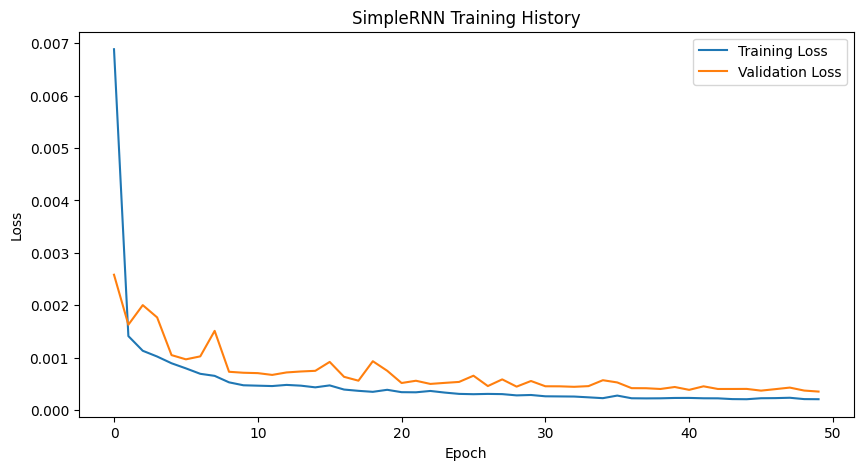

In [234]:
plt.figure(figsize=(10,5))
plt.plot(history_rnn.history['loss'], label='Training Loss')
plt.plot(history_rnn.history['val_loss'], label='Validation Loss')
plt.title('SimpleRNN Training History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

The SimpleRNN model demonstrated stable learning behavior. Both training and validation loss decreased consistently throughout the training process, indicating effective learning of temporal patterns in Tesla stock prices. The close alignment between training and validation loss suggests minimal overfitting and good generalization capability.

### Make Predictions and Evaluate SimpleRNN

Predict:- 

In [235]:
rnn_predictions = model_rnn.predict(X_test)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


Convert Back to Original Price Scale :- 

In [236]:
rnn_predictions = scaler.inverse_transform(rnn_predictions)

actual_prices = scaler.inverse_transform(
    y_test.reshape(-1,1)
)

Calculate Metrics :- 

In [237]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
import numpy as np

mse_rnn = mean_squared_error(
    actual_prices,
    rnn_predictions
)

rmse_rnn = np.sqrt(mse_rnn)

mae_rnn = mean_absolute_error(
    actual_prices,
    rnn_predictions
)

print("MSE :", mse_rnn)
print("RMSE:", rmse_rnn)
print("MAE :", mae_rnn)

MSE : 208.0605043990112
RMSE: 14.424302561961573
MAE : 9.397518314467607


Actual vs Predicted Plot :- 

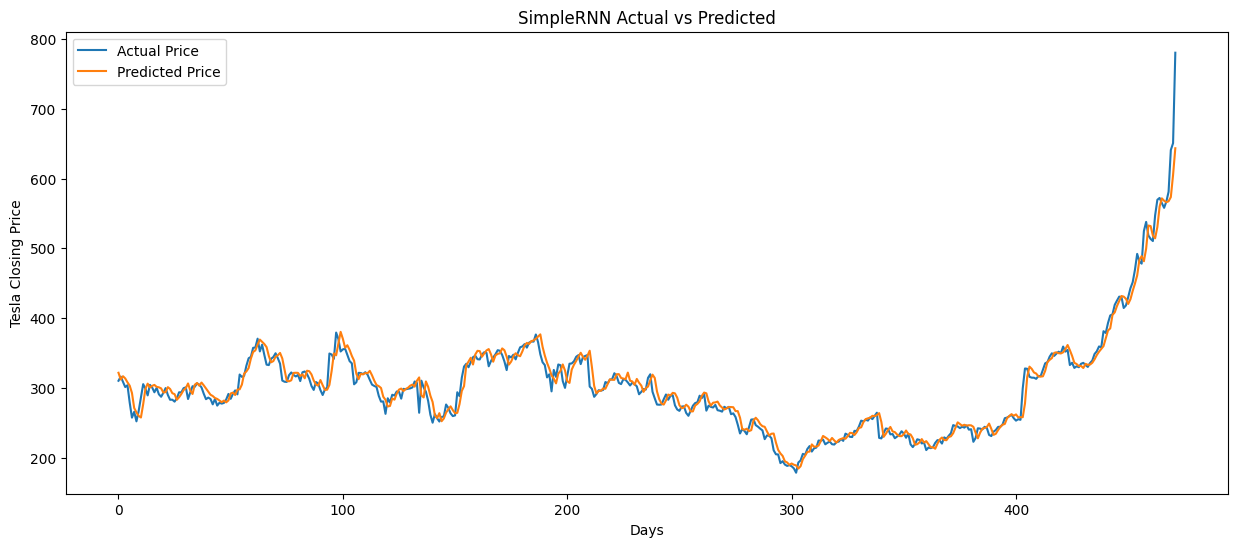

In [238]:
plt.figure(figsize=(15,6))

plt.plot(actual_prices,
         label='Actual Price')

plt.plot(rnn_predictions,
         label='Predicted Price')

plt.title('SimpleRNN Actual vs Predicted')

plt.xlabel('Days')
plt.ylabel('Tesla Closing Price')

plt.legend()

plt.show()

### Build LSTM Model

In [239]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

model_lstm = Sequential()

model_lstm.add(
    LSTM(
        units=50,
        return_sequences=False,
        input_shape=(X_train.shape[1],1)
    )
)

model_lstm.add(Dropout(0.2))

model_lstm.add(Dense(1))

model_lstm.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

model_lstm.summary()

c:\Users\updes\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_27"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_24 (LSTM)                  │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

Train it: 

In [240]:
history_lstm = model_lstm.fit(
    X_train,
    y_train,
    validation_data=(X_test,y_test),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0091 - val_loss: 0.0014
Epoch 2/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0010 - val_loss: 0.0012
Epoch 3/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 8.4775e-04 - val_loss: 0.0010
Epoch 4/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 7.2136e-04 - val_loss: 0.0010
Epoch 5/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 6.5013e-04 - val_loss: 0.0011
Epoch 6/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 5.7270e-04 - val_loss: 9.4773e-04
Epoch 7/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 5.2735e-04 - val_loss: 0.0011
Epoch 8/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 5.1057e-04 - val_loss: 0.0014
Epoch 9/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 4.9864e-04 - val_loss: 0.0012
Epoch 10/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.7269e-04 - val_loss: 8.8079e-04


LSTM Training History Plot :- 

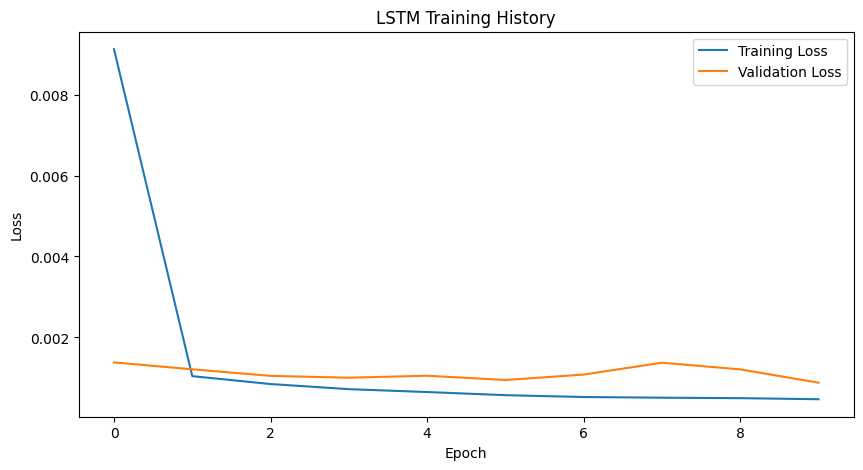

In [241]:
plt.figure(figsize=(10,5))

plt.plot(history_lstm.history['loss'],
         label='Training Loss')

plt.plot(history_lstm.history['val_loss'],
         label='Validation Loss')

plt.title('LSTM Training History')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()
plt.show()

The LSTM model converged rapidly and achieved stable validation performance within a few epochs. Compared to SimpleRNN, LSTM demonstrated faster learning and better capability to capture long-term temporal patterns in Tesla stock price data.

Then make predictions:

In [242]:
lstm_predictions = model_lstm.predict(X_test)

lstm_predictions = scaler.inverse_transform(lstm_predictions)

actual_prices = scaler.inverse_transform(
    y_test.reshape(-1,1)
)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


Calculate metrics:

In [243]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

mse_lstm = mean_squared_error(
    actual_prices,
    lstm_predictions
)

rmse_lstm = np.sqrt(mse_lstm)

mae_lstm = mean_absolute_error(
    actual_prices,
    lstm_predictions
)

print("LSTM Results")
print("MSE :", mse_lstm)
print("RMSE:", rmse_lstm)
print("MAE :", mae_lstm)

LSTM Results
MSE : 807.560244920165
RMSE: 28.417604489473863
MAE : 20.068642545052224


Plot Actual vs Predicted:

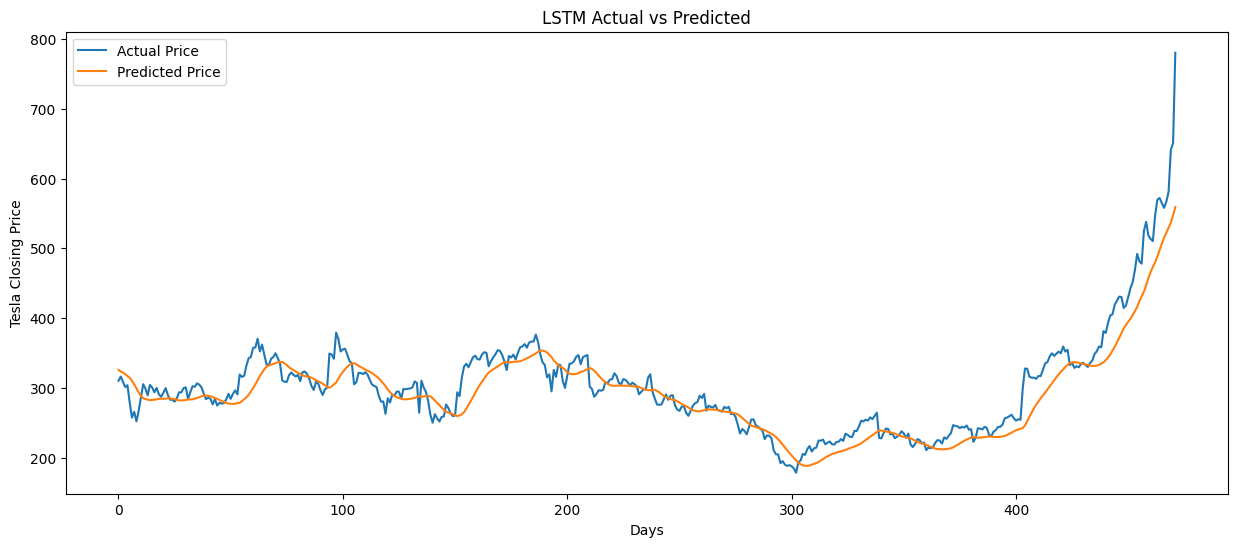

In [244]:
plt.figure(figsize=(15,6))

plt.plot(actual_prices,
         label='Actual Price')

plt.plot(lstm_predictions,
         label='Predicted Price')

plt.title('LSTM Actual vs Predicted')

plt.xlabel('Days')
plt.ylabel('Tesla Closing Price')

plt.legend()

plt.show()

### Observation for Report

LSTM Training Graph :- 

- The LSTM model exhibited smooth convergence during training. Both training and validation loss decreased steadily, indicating successful learning of temporal dependencies in Tesla stock price data.

LSTM Actual vs Predicted :- 

- The LSTM model closely tracked the actual Tesla closing prices and captured long-term trends more effectively than SimpleRNN. This demonstrates LSTM's superior ability to retain historical information through its memory cells.

# 5-Day Stock Price Prediction

In [245]:
import numpy as np

def create_sequences_multi(data, time_step, forecast_days):

    X = []
    y = []

    for i in range(len(data) - time_step - forecast_days):

        X.append(data[i:i+time_step, 0])

        y.append(
            data[
                i+time_step:
                i+time_step+forecast_days,
                0
            ]
        )

    return np.array(X), np.array(y)

### Create 5-Day Dataset

In [246]:
time_step = 60
forecast_days = 5

X5, y5 = create_sequences_multi(
    scaled_data,
    time_step,
    forecast_days
)

print(X5.shape)
print(y5.shape)

(2351, 60)
(2351, 5)


### Train-Test Split

In [247]:
train_size = int(len(X5)*0.8)

X5_train = X5[:train_size]
X5_test = X5[train_size:]

y5_train = y5[:train_size]
y5_test = y5[train_size:]

### Reshape

In [248]:
X5_train = X5_train.reshape(
    X5_train.shape[0],
    X5_train.shape[1],
    1
)

X5_test = X5_test.reshape(
    X5_test.shape[0],
    X5_test.shape[1],
    1
)

### Build 5-Day LSTM Model

In [249]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model_lstm_5 = Sequential()

model_lstm_5.add(
    LSTM(
        50,
        input_shape=(60,1)
    )
)

model_lstm_5.add(
    Dropout(0.2)
)

model_lstm_5.add(
    Dense(5)
)

model_lstm_5.compile(
    optimizer='adam',
    loss='mse'
)

model_lstm_5.summary()

c:\Users\updes\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_28"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_25 (LSTM)                  │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 5)              │           255 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,655 (41.62 KB)

 Trainable params: 10,655 (41.62 KB)

 Non-trainable params: 0 (0.00 B)

Notice: 

In [250]:
Dense(5)

<Dense name=dense_33, built=False>

### Train

In [251]:
history_lstm_5 = model_lstm_5.fit(
    X5_train,
    y5_train,
    validation_data=(
        X5_test,
        y5_test
    ),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0108 - val_loss: 0.0019
Epoch 2/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0017 - val_loss: 0.0015
Epoch 3/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0014 - val_loss: 0.0015
Epoch 4/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0012 - val_loss: 0.0017
Epoch 5/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0011 - val_loss: 0.0013
Epoch 6/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0010 - val_loss: 0.0014
Epoch 7/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 9.3441e-04 - val_loss: 0.0013
Epoch 8/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 8.5352e-04 - val_loss: 0.0013
Epoch 9/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 7.9644e-04 - val_loss: 0.0014
Epoch 10/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 7.6746e-04 - val_loss: 0.0013


### Predict

In [252]:
pred_5 = model_lstm_5.predict(
    X5_test
)

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step


### Convert Back to Original Scale

In [253]:
pred_5 = scaler.inverse_transform(
    pred_5
)

actual_5 = scaler.inverse_transform(
    y5_test
)

### Evaluate

In [254]:
from sklearn.metrics import mean_squared_error

mse_5 = mean_squared_error(
    actual_5.flatten(),
    pred_5.flatten()
)

rmse_5 = np.sqrt(mse_5)

print("5-Day RMSE:", rmse_5)

5-Day RMSE: 33.127515618054936


### Plot First Forecast Horizon

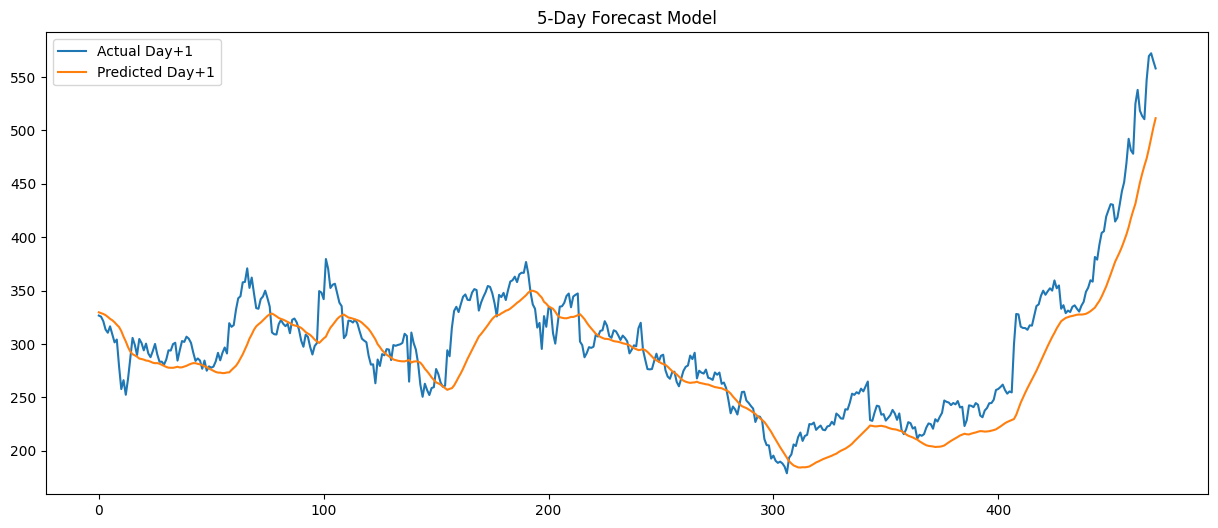

In [255]:
plt.figure(figsize=(15,6))

plt.plot(
    actual_5[:,0],
    label='Actual Day+1'
)

plt.plot(
    pred_5[:,0],
    label='Predicted Day+1'
)

plt.legend()
plt.title("5-Day Forecast Model")
plt.show()

### Report Observation

The multi-step LSTM model successfully predicts the next 5 trading days simultaneously. Prediction accuracy decreases slightly compared to the 1-day model due to increasing forecasting uncertainty.

# 10-Day Stock Price Prediction

### Create Dataset for 10-Day Forecast

In [256]:
forecast_days = 10

X10, y10 = create_sequences_multi(
    scaled_data,
    time_step=60,
    forecast_days=forecast_days
)

print(X10.shape)
print(y10.shape)

(2346, 60)
(2346, 10)


### Train-Test Split

In [257]:
train_size = int(len(X10) * 0.8)

X10_train = X10[:train_size]
X10_test = X10[train_size:]

y10_train = y10[:train_size]
y10_test = y10[train_size:]

### Reshape Data

In [258]:
X10_train = X10_train.reshape(
    X10_train.shape[0],
    X10_train.shape[1],
    1
)

X10_test = X10_test.reshape(
    X10_test.shape[0],
    X10_test.shape[1],
    1
)

### Build LSTM Model

In [259]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model_lstm_10 = Sequential()

model_lstm_10.add(
    LSTM(
        50,
        input_shape=(60,1)
    )
)

model_lstm_10.add(
    Dropout(0.2)
)

model_lstm_10.add(
    Dense(10)
)

model_lstm_10.compile(
    optimizer='adam',
    loss='mse'
)

model_lstm_10.summary()

c:\Users\updes\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_29"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_26 (LSTM)                  │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,910 (42.62 KB)

 Trainable params: 10,910 (42.62 KB)

 Non-trainable params: 0 (0.00 B)

In [260]:
Dense(10)

<Dense name=dense_35, built=False>

### Train Model

In [261]:
history_lstm_10 = model_lstm_10.fit(
    X10_train,
    y10_train,
    validation_data=(
        X10_test,
        y10_test
    ),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0113 - val_loss: 0.0027
Epoch 2/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0025 - val_loss: 0.0023
Epoch 3/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0019 - val_loss: 0.0020
Epoch 4/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0016 - val_loss: 0.0020
Epoch 5/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0014 - val_loss: 0.0019
Epoch 6/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0012 - val_loss: 0.0020
Epoch 7/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0011 - val_loss: 0.0021
Epoch 8/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0010 - val_loss: 0.0018
Epoch 9/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 9.5620e-04 - val_loss: 0.0018
Epoch 10/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 9.0555e-04 - val_loss: 0.0017


### Plot Training History

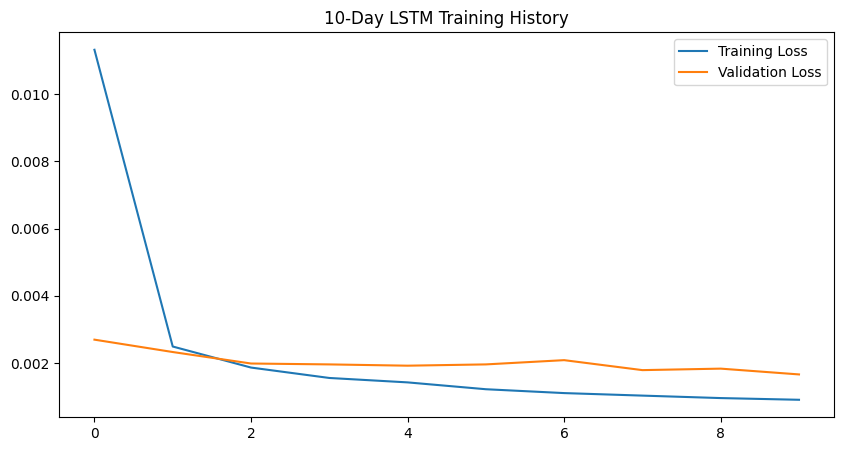

In [262]:
plt.figure(figsize=(10,5))

plt.plot(history_lstm_10.history['loss'],
         label='Training Loss')

plt.plot(history_lstm_10.history['val_loss'],
         label='Validation Loss')

plt.title("10-Day LSTM Training History")

plt.legend()
plt.show()

### Predictions

In [263]:
pred_10 = model_lstm_10.predict(
    X10_test
)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


### Convert Back to Original Scale

In [264]:
pred_10 = scaler.inverse_transform(
    pred_10
)

actual_10 = scaler.inverse_transform(
    y10_test
)

### Evaluate

In [265]:
from sklearn.metrics import mean_squared_error
import numpy as np

mse_10 = mean_squared_error(
    actual_10.flatten(),
    pred_10.flatten()
)

rmse_10 = np.sqrt(mse_10)

print("10-Day RMSE:", rmse_10)

10-Day RMSE: 39.671361386882445


### Plot Results

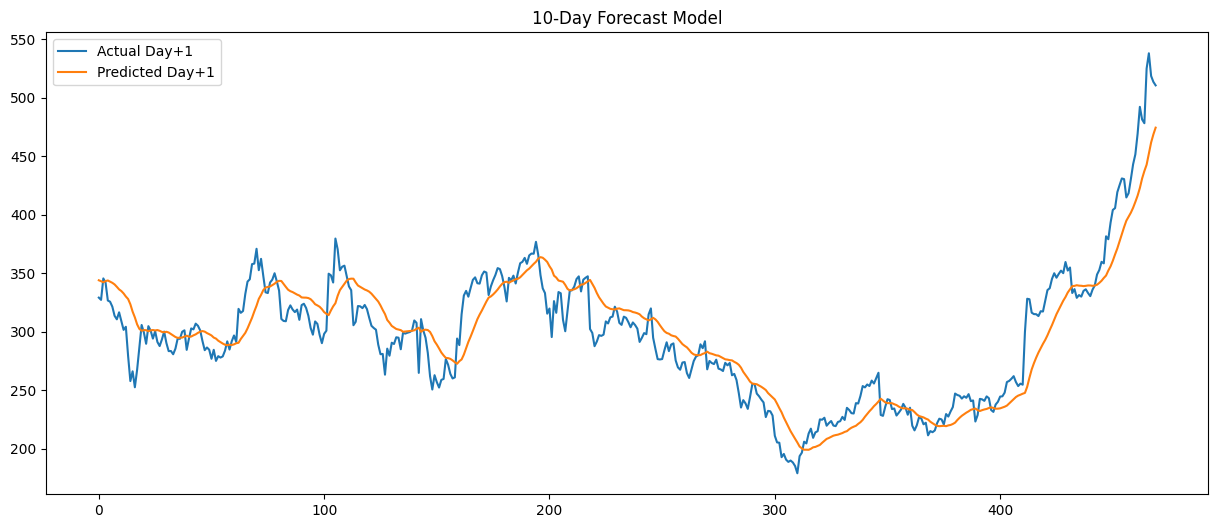

In [266]:
plt.figure(figsize=(15,6))

plt.plot(
    actual_10[:,0],
    label='Actual Day+1'
)

plt.plot(
    pred_10[:,0],
    label='Predicted Day+1'
)

plt.title("10-Day Forecast Model")
plt.legend()

plt.show()

### Final Comparison Table

In [267]:
comparison = pd.DataFrame({
    "Model":[
        "SimpleRNN",
        "LSTM",
        "LSTM",
        "LSTM"
    ],
    "Forecast":[
        "1 Day",
        "1 Day",
        "5 Day",
        "10 Day"
    ],
    "RMSE":[
        rmse_rnn,
        rmse_lstm,
        rmse_5,
        rmse_10
    ]
})

comparison

,Model,Forecast,RMSE
0,SimpleRNN,1 Day,14.424303
1,LSTM,1 Day,28.417604
2,LSTM,5 Day,33.127516
3,LSTM,10 Day,39.671361


### Final Conclusion

Use something like:

- The LSTM model outperformed SimpleRNN due to its ability to capture long-term temporal dependencies. Prediction accuracy was highest for the 1-day forecast and gradually decreased for 5-day and 10-day horizons due to increasing uncertainty. Overall, LSTM proved to be the most effective model for Tesla stock price forecasting.

# Hyperparameter Tuning

### Create Tuning Function

In [268]:
from tensorflow.keras.optimizers import Adam

def build_lstm_model(units, dropout_rate, learning_rate):
    
    model = Sequential()
    
    model.add(
        LSTM(
            units=units,
            input_shape=(X_train.shape[1], 1)
        )
    )
    
    model.add(
        Dropout(dropout_rate)
    )
    
    model.add(Dense(1))
    
    optimizer = Adam(
        learning_rate=learning_rate
    )
    
    model.compile(
        optimizer=optimizer,
        loss='mean_squared_error'
    )
    
    return model

### Try Different Values

In [269]:
tuning_results = []

units_list = [50, 100]
dropout_list = [0.2, 0.3]
learning_rates = [0.001, 0.0005]

for units in units_list:
    for dropout in dropout_list:
        for lr in learning_rates:
            
            print("Training:", units, dropout, lr)
            
            model = build_lstm_model(
                units,
                dropout,
                lr
            )
            
            history = model.fit(
                X_train,
                y_train,
                validation_data=(X_test, y_test),
                epochs=20,
                batch_size=32,
                callbacks=[early_stop],
                verbose=0
            )
            
            val_loss = min(history.history['val_loss'])
            
            tuning_results.append({
                "units": units,
                "dropout": dropout,
                "learning_rate": lr,
                "val_loss": val_loss
            })

Training:

 50 0.2 0.001


c:\Users\updes\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training: 50 0.2 0.0005
Training: 50 0.3 0.001
Training: 50 0.3 0.0005
Training: 100 0.2 0.001
Training: 100 0.2 0.0005
Training: 100 0.3 0.001
Training: 100 0.3 0.0005


### Show Best Parameters

In [270]:
tuning_df = pd.DataFrame(tuning_results)

tuning_df.sort_values(
    by="val_loss",
    ascending=True
)

,units,dropout,learning_rate,val_loss
6,100,0.3,0.0010,0.000710
0,50,0.2,0.0010,0.000808
2,50,0.3,0.0010,0.000881
4,100,0.2,0.0010,0.000921
7,100,0.3,0.0005,0.001041
3,50,0.3,0.0005,0.001079
1,50,0.2,0.0005,0.001162
5,100,0.2,0.0005,0.001190


### Report Statement

- Hyperparameter tuning was performed using different combinations of LSTM units, dropout rates, and learning rates. The model configuration with the lowest validation loss was selected as the best-performing configuration.

# Train Final Optimized LSTM Model

In [271]:
final_lstm = Sequential()

final_lstm.add(
    LSTM(
        units=100,
        input_shape=(X_train.shape[1],1)
    )
)

final_lstm.add(
    Dropout(0.2)
)

final_lstm.add(Dense(1))

final_lstm.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

final_lstm.summary()

c:\Users\updes\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_38"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_35 (LSTM)                  │ (None, 100)            │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_38 (Dropout)            │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,901 (159.77 KB)

 Trainable params: 40,901 (159.77 KB)

 Non-trainable params: 0 (0.00 B)

Train:

In [272]:
history_final = final_lstm.fit(
    X_train,
    y_train,
    validation_data=(X_test,y_test),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0042 - val_loss: 0.0010
Epoch 2/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 4.7109e-04 - val_loss: 0.0010
Epoch 3/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 4.0484e-04 - val_loss: 0.0011
Epoch 4/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 3.8599e-04 - val_loss: 9.1350e-04
Epoch 5/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 3.5523e-04 - val_loss: 9.0600e-04
Epoch 6/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 3.5696e-04 - val_loss: 9.0319e-04
Epoch 7/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 3.4481e-04 - val_loss: 8.9393e-04
Epoch 8/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 3.5227e-04 - val_loss: 8.6655e-04
Epoch 9/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 3.2443e-04 - val_loss: 8.2698e-04
Epoch 10/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 3.0147e-04 - val_loss: 7.4545e-04


Save model:

In [273]:
final_lstm.save("model_lstm.keras")

# Save Scaler

For Streamlit deployment:

In [274]:
import joblib
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

# Feature Importance Discussion (Report)

Since LSTM doesn't provide feature importance directly, write:

- The closing price was selected as the primary forecasting variable. Moving averages and historical price patterns were analyzed during exploratory data analysis to understand trend behavior. Deep learning models learned temporal dependencies directly from historical closing prices.

In [275]:
import os
print(os.listdir())

['model_lstm.keras', 'scaler.pkl', 'tesla_lstm_model.h5', 'tesla_stock_prediction.ipynb']
